# 하수 surcharge 센서 진위감사 (sewer surcharge authenticity audit)

**목적**: `is_surcharge`(fill_rate≥1, 만관) 플래그가 *진짜 강우성 만관*인지 *센서 아티팩트(stuck/capacity 오류)*인지 센서별로 가른다.
도로 라벨 감사(`label_quality_audit`)와 동일 철학 — 사용자 가설 *강우→하수 만관→월류→침수*의 1단계(만관)가 실재하는 센서를 확정한다.

**판정 신호**
- **강우 lift** = (surcharge 시점의 최근6h 강우율) ÷ (평상시 강우율). lift≥2면 surcharge가 강우에 집중 = 진짜 강우성 만관. (nearest 공공강우, 2024-01~2025-08만 검증가능)
- **capacity에러**: 전체 fill_rate 중앙값≥0.9 = 관이 *항상* 만관 초과 = 관높이 과소설정(허위 surcharge).
- **stuck_천장**: surcharge fill이 정확히 1.0에 핀(pinned) = 천장 saturation 고착.
- **stuck_구간**: surcharge가 stuck 세그먼트 안.
- **미검증**: surcharge가 2022년 등 강우 커버리지 밖(검증 불가).

⚠️ 공공강우는 ~1.5km 거리라 국지성 호우를 놓침 → lift는 **하한**(진짜 강우성 만관을 과소 추정). AWS 1분 강우 확보 시 재검증.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
EB="dataset/processed/eda_based/"

sf = pd.read_parquet(EB+"sewer_features_10min.parquet",
        columns=['sewer_sensor_id','ts10','fill_rate','is_surcharge','is_stuck_seg'])
print("행:", len(sf), "| 센서:", sf.sewer_sensor_id.nunique())
print("기간:", sf.ts10.min(), "~", sf.ts10.max())
print("is_surcharge 합:", int(sf.is_surcharge.sum()), "| 비율%:", round(sf.is_surcharge.mean()*100,3))

행: 51560086 | 센서: 485
기간: 2022-01-01 00:00:00 ~ 2025-08-31 23:50:00
is_surcharge 합: 94931 | 비율%: 0.184


## 1. 센서별 surcharge 구조 지표 (전 기간, 강우 불필요)

In [2]:
S = sf[sf.is_surcharge==1].copy()
S['year']=S.ts10.dt.year
fillmed = sf.groupby('sewer_sensor_id').fill_rate.median().rename('fill_med_all')
ov = S.groupby('sewer_sensor_id').agg(
    n_surch=('ts10','size'),
    frac_2024p=('year', lambda x:(x>=2024).mean()),
    overshoot=('fill_rate', lambda x:(x>1.05).mean()),
    pinned1 =('fill_rate', lambda x:(np.abs(x-1)<1e-6).mean()),
    stuck_in_s=('is_stuck_seg','mean'))
print("surcharge 발생 센서:", len(ov))
ov.sort_values('n_surch',ascending=False).head(8).round(3)

surcharge 발생 센서: 223


,n_surch,frac_2024p,overshoot,pinned1,stuck_in_s
sewer_sensor_id,,,,,
11-0009,7596,0.000,0.773,0.029,0.115
19-0005,6523,0.154,0.000,1.000,0.984
17-0007,6211,0.913,0.000,1.000,0.312
23-0012,5663,0.015,0.000,1.000,0.000
14-0020,4212,0.000,1.000,0.000,0.549
01-0004,3940,0.119,0.990,0.001,0.000
25-0005,3892,0.692,0.000,1.000,0.484
11-0011,3772,0.000,0.190,0.810,0.574


## 2. 강우 lift — surcharge가 강우에 집중되나? (nearest 공공강우, 2024-01~)

In [3]:
m = pd.read_parquet("dataset/processed/sewer_rain_mapping.parquet")[['sensor_id','rain_station_id','distance_m']]
rf = pd.read_parquet(EB+"rain_features_10min.parquet",
        columns=['station_id','timestamp','is_recent_rain_6h'])
X = (sf.merge(m, left_on='sewer_sensor_id', right_on='sensor_id', how='left')
        .merge(rf, left_on=['rain_station_id','ts10'], right_on=['station_id','timestamp'], how='left'))
X = X[X.is_recent_rain_6h.notna()]   # 강우 커버되는 bin만 (2024-01~2025-08)

def lift(d):
    base = d.is_recent_rain_6h.mean(); s = d[d.is_surcharge==1]
    return pd.Series({'n_cov_surch':len(s),
        'base_rain6h':base,
        'surch_rain6h': s.is_recent_rain_6h.mean() if len(s) else np.nan,
        'lift': (s.is_recent_rain_6h.mean()/base) if (len(s)>0 and base>0) else np.nan})
L = X.groupby('sewer_sensor_id').apply(lift)
print("검증가능(강우커버) surcharge 센서:", int((L.n_cov_surch>=30).sum()))
L[L.n_cov_surch>=30].sort_values('lift',ascending=False).head(10).round(3)

검증가능(강우커버) surcharge 센서: 62


,n_cov_surch,base_rain6h,surch_rain6h,lift
sewer_sensor_id,,,,
20-0012,308.0,0.101,0.981,9.753
06-0009,896.0,0.107,0.276,2.582
11-0004,75.0,0.096,0.200,2.080
18-0018,1375.0,0.084,0.120,1.433
17-0007,5673.0,0.117,0.130,1.108
19-0005,1002.0,0.089,0.096,1.074
23-0088,46.0,0.265,0.174,0.657
25-0005,2116.0,0.098,0.048,0.492
23-0064,52.0,0.320,0.154,0.481


## 3. 분류 — 진짜 강우성 만관 vs 아티팩트

In [4]:
A = ov.join(fillmed).join(L).reset_index()
def classify(r):
    if r.fill_med_all>=0.9:                          return 'capacity에러'
    if (r.n_cov_surch>=30) and (r.lift>=2):          return '진짜_강우성만관'
    if r.pinned1>=0.8:                               return 'stuck_천장'
    if r.stuck_in_s>=0.6:                            return 'stuck_구간'
    if (r.frac_2024p<0.2) or (r.n_cov_surch<30):     return '미검증'
    return '비강우_모호'
A['판정']=A.apply(classify,axis=1)
print(A.판정.value_counts().to_string())

판정
미검증           77
stuck_천장      75
capacity에러    35
비강우_모호        29
stuck_구간       4
진짜_강우성만관       3


In [5]:
A[A.판정=='진짜_강우성만관'].sort_values('lift',ascending=False)[
   ['sewer_sensor_id','n_surch','overshoot','pinned1','stuck_in_s','fill_med_all','n_cov_surch','base_rain6h','surch_rain6h','lift']
].round(3)

,sewer_sensor_id,n_surch,overshoot,pinned1,stuck_in_s,fill_med_all,n_cov_surch,base_rain6h,surch_rain6h,lift
81,20-0012,2861,0.0,1.0,0.285,0.100,308.0,0.101,0.981,9.753
21,06-0009,896,1.0,0.0,1.000,0.022,896.0,0.107,0.276,2.582
39,11-0004,922,0.0,1.0,0.831,0.020,75.0,0.096,0.200,2.080


**핵심 결과**: 223개 surcharge 센서 중 공공강우로 **진짜 강우성 만관으로 확정되는 건 3개**(20-0012 lift 9.75 · 06-0009 2.58 · 11-0004 2.08).
나머지는 stuck(천장/구간)+capacity에러 = 명백 아티팩트, 2022년 등 미검증, 비강우 모호로 나뉜다.
binary `is_surcharge`는 도로 라벨처럼 **아티팩트 지배** — stuck+capacity 정제 없이 쓰면 안 됨.
단 공공강우 1.5km 한계로 3은 **하한**(AWS 1분 강우로 재검증 시 늘 수 있음).

## 4. 시각화

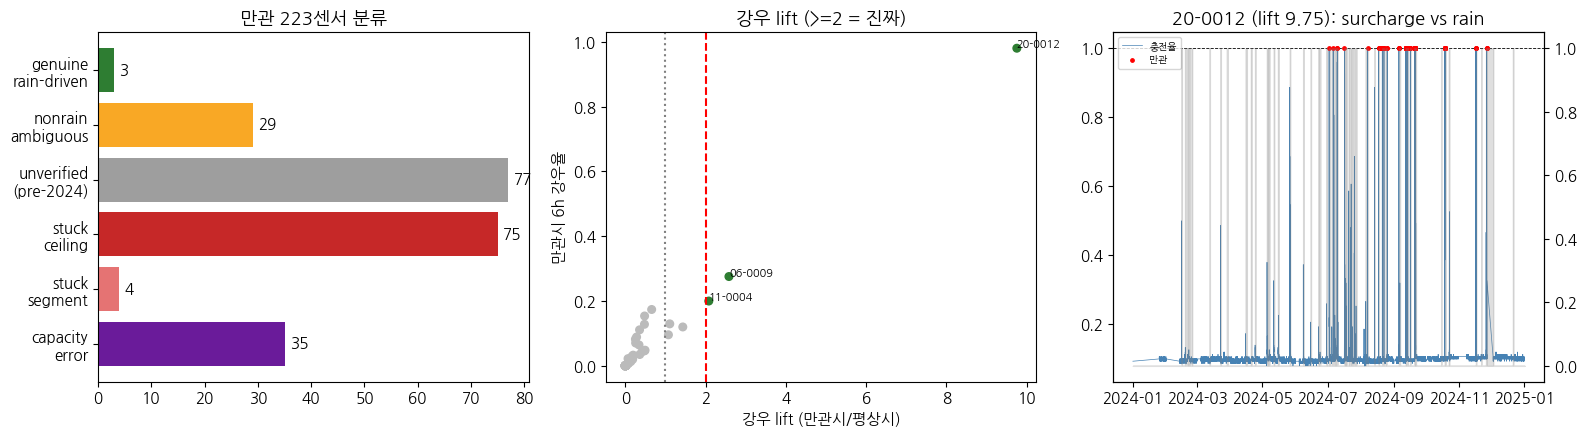

saved reports/figures_sewer/02_surcharge_audit.png


In [6]:
fig, ax = plt.subplots(1,3, figsize=(16,4.5))
order=['진짜_강우성만관','비강우_모호','미검증','stuck_천장','stuck_구간','capacity에러']
labels=['genuine\nrain-driven','nonrain\nambiguous','unverified\n(pre-2024)','stuck\nceiling','stuck\nsegment','capacity\nerror']
cnt=A.판정.value_counts().reindex(order).fillna(0)
colors=['#2e7d32','#f9a825','#9e9e9e','#c62828','#e57373','#6a1b9a']
ax[0].barh(labels, cnt.values, color=colors)
for i,v in enumerate(cnt.values): ax[0].text(v+1,i,int(v),va='center')
ax[0].set_title('만관 223센서 분류'); ax[0].invert_yaxis()

v=A[A.n_cov_surch>=30]
ax[1].scatter(v.lift, v.surch_rain6h, c=(v.lift>=2).map({True:'#2e7d32',False:'#bbbbbb'}), s=30)
ax[1].axvline(2, ls='--', c='r'); ax[1].axvline(1, ls=':', c='gray')
for _,r in v[v.lift>=2].iterrows(): ax[1].annotate(r.sewer_sensor_id,(r.lift,r.surch_rain6h),fontsize=8)
ax[1].set_xlabel('강우 lift (만관시/평상시)'); ax[1].set_ylabel('만관시 6h 강우율')
ax[1].set_title('강우 lift (>=2 = 진짜)')

best='20-0012'
d=X[(X.sewer_sensor_id==best)&(X.ts10.dt.year==2024)].sort_values('ts10')
ax2=ax[2]
ax2.plot(d.ts10, d.fill_rate, lw=0.5, c='steelblue', label='충전율')
sc=d[d.is_surcharge==1]; ax2.scatter(sc.ts10, sc.fill_rate, s=6, c='red', label='만관', zorder=3)
ax2b=ax2.twinx()
ax2b.fill_between(d.ts10, d.is_recent_rain_6h, color='gray', alpha=0.25, step='mid')
ax2.axhline(1, ls='--', c='k', lw=0.6)
ax2.set_title(f'{best} (lift 9.75): surcharge vs rain'); ax2.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('reports/figures_sewer/02_surcharge_audit.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved reports/figures_sewer/02_surcharge_audit.png')

## 5. 산출물 저장

In [7]:
out = A[['sewer_sensor_id','n_surch','frac_2024p','overshoot','pinned1','stuck_in_s',
         'fill_med_all','n_cov_surch','base_rain6h','surch_rain6h','lift','판정']].copy()
out.to_parquet(EB+"sewer_surcharge_audit.parquet", index=False)
print("저장:", EB+"sewer_surcharge_audit.parquet", "| 행:", len(out))
print(out.판정.value_counts().to_string())

저장: dataset/processed/eda_based/sewer_surcharge_audit.parquet | 행: 223
판정
미검증           77
stuck_천장      75
capacity에러    35
비강우_모호        29
stuck_구간       4
진짜_강우성만관       3


## 결론
- **surcharge 223센서 중 진짜 강우성 만관은 3개(20-0012·06-0009·11-0004)** — 공공강우 lift≥2로 확정. 20-0012는 강우시 만관율 98%(lift 9.75)로 가장 강한 증거.
- **아티팩트 다수**: stuck_천장 75 + stuck_구간 4 + capacity에러 35 = 114센서가 명백 비강우 허위 surcharge. 특히 **22/23구역 다수 센서는 fill 중앙값>1 = 관높이 과소설정**(capacity 재교정 필요).
- **미검증 77**: surcharge가 2022년(강우 커버 밖). AWS는 2023~만 가능 → 일부만 추후 검증.
- **비강우 모호 29**: 물리적 overshoot이나 공공강우 무동반 — 1.5km 게이지가 국지호우 놓쳤거나 비강우 만관. **AWS 1분 강우로 재검증 대상**.
- → 다음: ① 확정 3센서(+AWS 재검증분) ↔ 도로 침수지점(확정6/co-located) 시공간 동조 = *강우→만관→침수* 사슬. ② 22/23구역 capacity 재교정.